#### Classification task



In [1]:
from sklearn.datasets import load_breast_cancer
data=load_breast_cancer()
X=data.data
y=data.target

In [2]:
print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [3]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [4]:
#creating forest of 100 trees
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(
    n_estimators=100,random_state=42
)

In [5]:
rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [6]:
y_pred=rf.predict(X_test)

In [7]:
from sklearn.metrics import accuracy_score
print('Accuracy  : ',accuracy_score(y_test,y_pred))

Accuracy  :  0.9649122807017544


In [8]:
from sklearn.metrics import classification_report
print("Classification Report :\n",classification_report(y_test,y_pred))

Classification Report :
               precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [9]:
import pandas as pd
importance=pd.DataFrame(
    {"Feature": data.feature_names,
    "Importance" : rf.feature_importances_}
)
print(
    importance.sort_values(
        by="Importance",
        ascending=False
    )
)


                    Feature  Importance
23               worst area    0.153892
27     worst concave points    0.144663
7       mean concave points    0.106210
20             worst radius    0.077987
6            mean concavity    0.068001
22          worst perimeter    0.067115
2            mean perimeter    0.053270
0               mean radius    0.048703
3                 mean area    0.047555
26          worst concavity    0.031802
13               area error    0.022407
21            worst texture    0.021749
25        worst compactness    0.020266
10             radius error    0.020139
5          mean compactness    0.013944
1              mean texture    0.013591
12          perimeter error    0.011303
24         worst smoothness    0.010644
28           worst symmetry    0.010120
16          concavity error    0.009386
4           mean smoothness    0.007285
19  fractal dimension error    0.005321
15        compactness error    0.005253
29  worst fractal dimension    0.005210


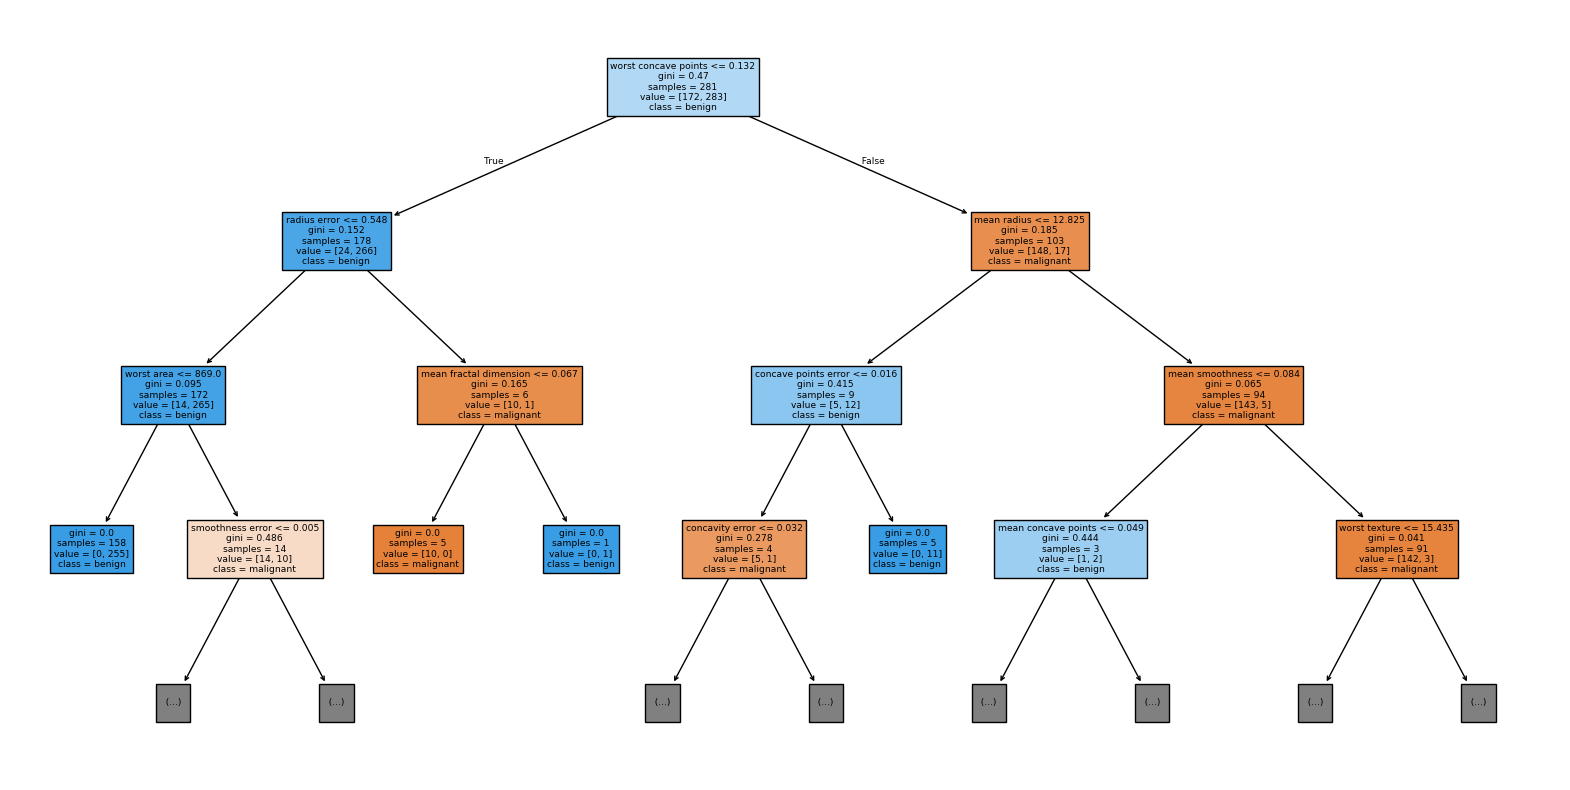

In [10]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(
    rf.estimators_[0],
    filled=True,
    max_depth=3,
    feature_names=data.feature_names,
    class_names=data.target_names
)
plt.show()

### Regression Task


In [11]:
from sklearn.datasets import fetch_california_housing
housing=fetch_california_housing()
X=housing.data
y=housing.target

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.8,random_state=42)

In [13]:
from sklearn.ensemble import RandomForestRegressor
rf_reg=RandomForestRegressor(
    n_estimators=120,
    random_state=42,
    
)

In [14]:
rf_reg.fit(X_train,y_train)

RandomForestRegressor(n_estimators=120, random_state=42)

In [15]:
y_pred=rf_reg.predict(X_test)

In [16]:
from sklearn.metrics import mean_absolute_error,r2_score

mae = mean_absolute_error(
    y_test,
    y_pred
)
r2=r2_score(y_test,y_pred)

print("mae",mae)#if median house price=100000$ on avg, model prediction differs from the actual house price by about $37,500(0.375*100000).
print("r2: ",r2)

mae 0.375371671027132
r2:  0.7698052074120525


In [17]:
#checking for overfitting
print(rf_reg.score(X_train,y_train))
print(rf_reg.score(X_test,y_test))


0.9667547608830759
0.7698052074120525


In [22]:
rf_reg_1=RandomForestRegressor(
    max_depth=15,
    min_samples_leaf=10,
    n_estimators=300,
    random_state=42
)

In [23]:
rf_reg_1.fit(X_train,y_train)

RandomForestRegressor(max_depth=15, min_samples_leaf=10, n_estimators=300,
                      random_state=42)

In [24]:
y_pred=rf_reg_1.predict(X_test)
print(rf_reg_1.score(X_train,y_train))
print(rf_reg_1.score(X_test,y_test))


0.8332240231383735
0.7539511623835324


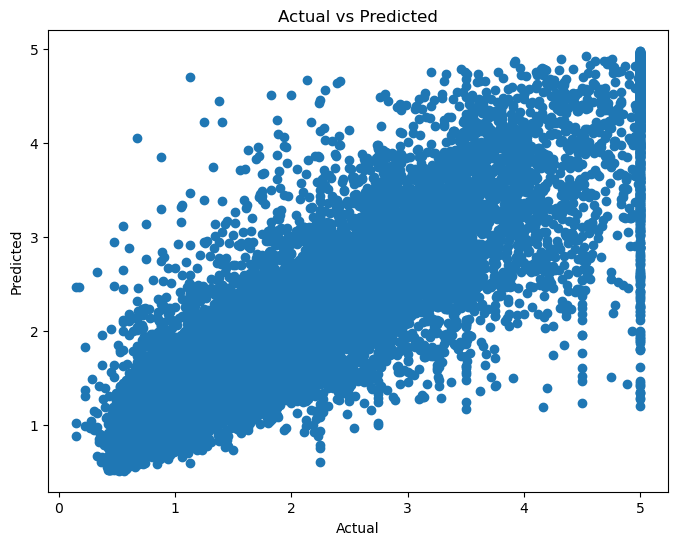

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()